**Column Details:**
- **country**: Name of the country.
- **child_mort**: Number of child deaths per 1,000 live births (under 5 years).
- **exports**: Percentage of GDP that comes from exports.
- **health**: Percentage of GDP spent on healthcare.
- **imports**: Percentage of GDP spent on imports.
- **income**: Average income per person (per capita income in USD).
- **inflation**: Annual inflation rate (percentage change in prices).
- **life_expec**: Average life expectancy at birth (in years).
- **total_fer**: Average number of children born to a woman during her lifetime.
- **gdpp**: Gross Domestic Product per capita (in USD).


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
pd.options.display.float_format = '{:.2f}'.format
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

import plotly.express as px
!pip install -U kaleido
import kaleido

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 6.1 MB/s eta 0:00:00


In [2]:
df = pd.read_csv("/content/Country-data.csv")

In [3]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
df.shape

(167, 10)

In [6]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.00,38.27,40.33,2.60,8.25,19.30,62.10,208.00
exports,167.00,41.11,27.41,0.11,23.80,35.00,51.35,200.00
health,167.00,6.82,2.75,1.81,4.92,6.32,8.60,17.90
imports,167.00,46.89,24.21,0.07,30.20,43.30,58.75,174.00
income,167.00,17144.69,19278.07,609.00,3355.00,9960.00,22800.00,125000.00
inflation,167.00,7.78,10.57,-4.21,1.81,5.39,10.75,104.00
life_expec,167.00,70.56,8.89,32.10,65.30,73.10,76.80,82.80
total_fer,167.00,2.95,1.51,1.15,1.79,2.41,3.88,7.49
gdpp,167.00,12964.16,18328.70,231.00,1330.00,4660.00,14050.00,105000.00


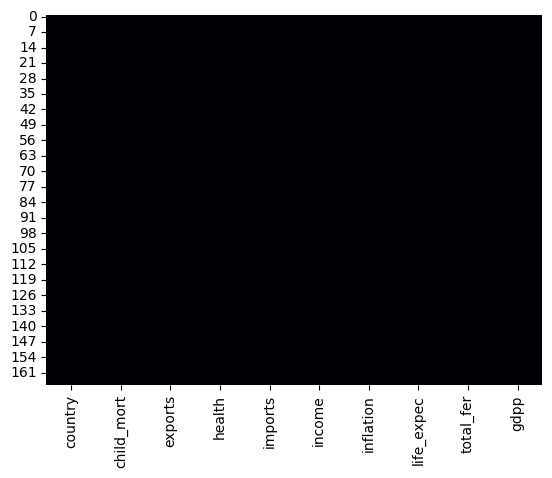

In [10]:
sns.heatmap(df.isnull(), cmap = 'magma', cbar=False);

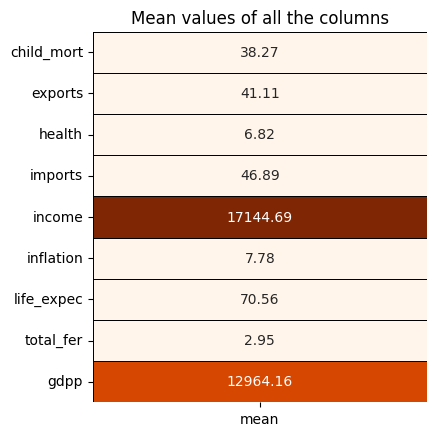

In [18]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,5))
colors = ['#FF781F', '#2D2926']
plt.subplot(1, 1, 1)
sns.heatmap(df.describe().T[['mean']], cmap='Oranges', annot=True, fmt='.2f',
            linecolor='black', linewidths=0.4, cbar=False);
plt.title("Mean values of all the columns");
fig.tight_layout(pad=3)

In [21]:
col = df.dtypes == 'object'
obj_cols = list(col[col].index)
col = df.dtypes != 'object'
num_cols = list(col[col].index)
print("Categorical Columns are: ", obj_cols)
print("Numerical Columns are: ", num_cols)

Categorical Columns are:  ['country']
Numerical Columns are:  ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


* We have only a few columns.
* Clearly 'country' is the only categorical column, rest are numerical columns.
* We separated categorical and numerical column.


#EDA

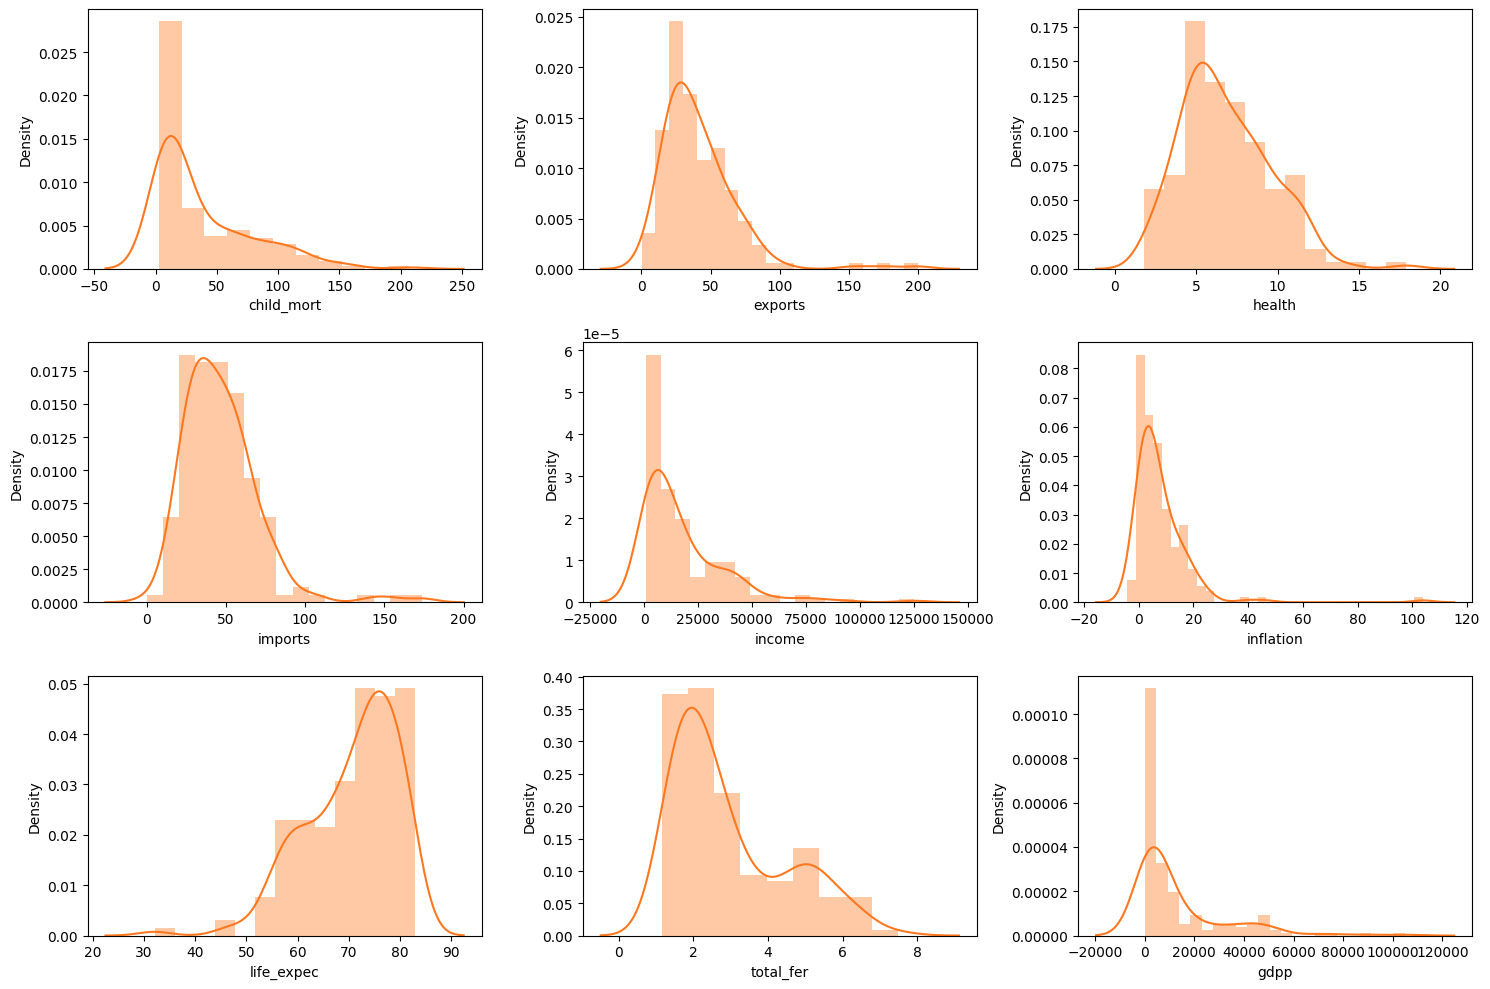

In [26]:
# let's observe the data distribution of all the numerical columns
plt.figure(figsize=(15, 10))
index=0
for col in num_cols:
    index += 1
    plt.subplot(3, 3, index)
    sns.distplot(df[col], color=colors[0])
    # plt.sup_title('Distribution of numerical features')
    plt.tight_layout()
plt.show()

In [27]:
len(df['country'].unique()) == len(df)

True

* Mostly all the columns appears to be right skewed or positively skewed distribution.
* Only column called ['life_expec'] appears left skewed or negatively skewed distribution.
* Only ['health'] column has normally distributed values.

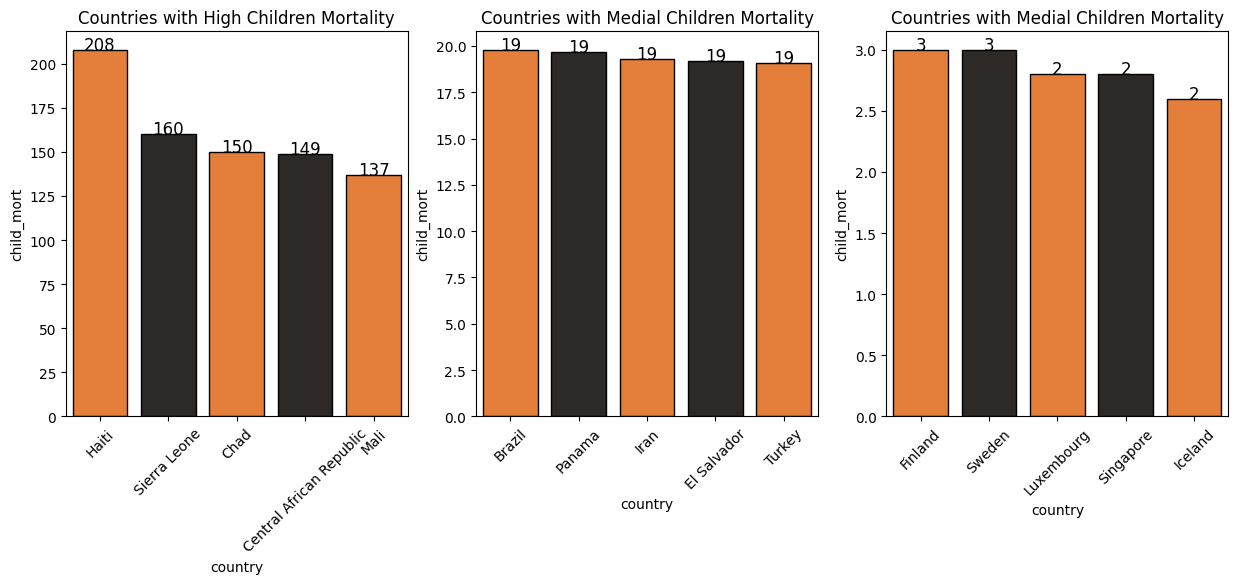

In [40]:
fig = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
plt.subplot(1, 3, 1)
ax = sns.barplot(x= 'country', y='child_mort',
                 data = df.sort_values(ascending=False, by='child_mort').iloc[:5],
                 palette = colors, edgecolor='black');
plt.title("Countries with High Children Mortality")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(), int(rect.get_height()),
            horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 2)
ax = sns.barplot(x='country', y='child_mort',
                 data = df.sort_values(ascending=False, by='child_mort').iloc[81:86],
                 palette = colors, edgecolor='black');
plt.title("Countries with Medial Children Mortality")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(), int(rect.get_height()),
            horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 3)
ax = sns.barplot(x='country', y='child_mort',
                 data = df.sort_values(ascending=False, by='child_mort').iloc[-5:],
                 palette = colors, edgecolor='black');
plt.title("Countries with Medial Children Mortality")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(), int(rect.get_height()),
            horizontalalignment='center', fontsize=12)

* Haiti has the most death occuring to children, African countries has significant positions in the statistic.
* At the other extreme Asia and Europe countries has solid presence.

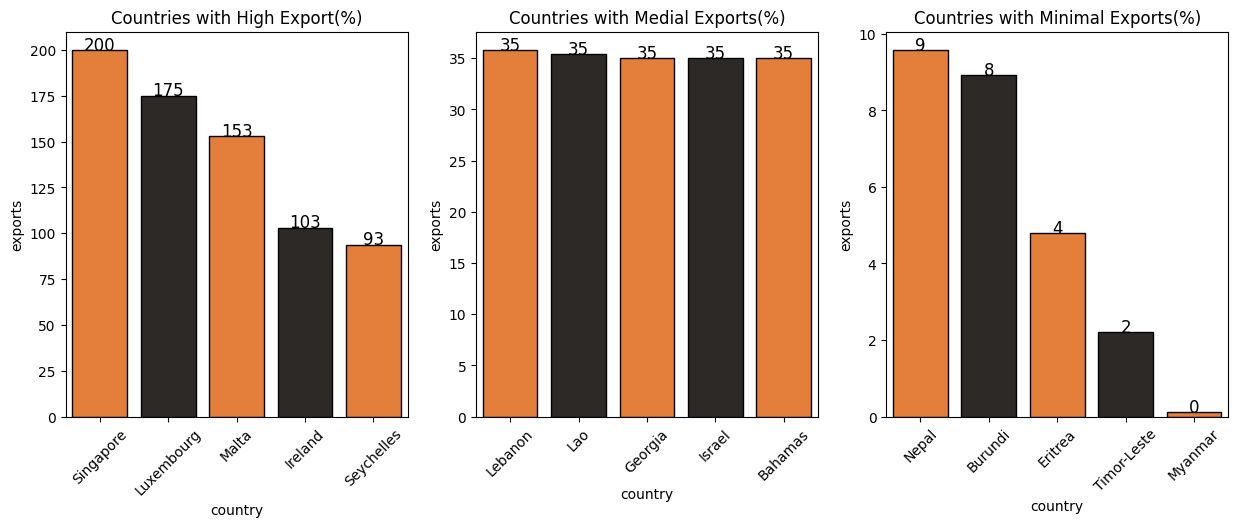

In [50]:
fig = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
plt.subplot(1, 3, 1)
ax = sns.barplot(x = 'country', y='exports',
                 data = df.sort_values(ascending=False, by='exports').iloc[:5],
                 palette = colors, edgecolor='black')
plt.title("Countries with High Export(%)")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height(),
            int(rect.get_height()), horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 2)
ax = sns.barplot(x='country', y='exports',
                 data=df.sort_values(ascending=False, by='exports').iloc[81:86],
                 palette=colors, edgecolor='black')
plt.title("Countries with Medial Exports(%)")
plt.xticks(rotation=45)
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height(),
            int(rect.get_height()), horizontalalignment='center', fontsize=12)

plt.subplot(1, 3, 3)
ax = sns.barplot(x='country', y='exports',
                 data = df.sort_values(ascending=False, by='exports').iloc[-5:],
                 palette=colors, edgecolor='black')
plt.title("Countries with Minimal Exports(%)")
plt.xticks(rotation=(45))
for rect in ax.patches:
    ax.text(rect.get_x()+rect.get_width()/2, rect.get_height(),
            int(rect.get_height()), horizontalalignment='center', fontsize=12)


* Singapore has the highest export even if their population is not the largest.
* Afganistan and Nepal are present at the lower end of export rankings and apparently Myanmar has no export at all.